# NIH XRay MRI Classification

#  MobileNetV2 -- Binary classification between No Finding and "Finding"
### Author: Ethan Gilles, Phil Lane

---

## Importing libraries

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import timm
import random
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

## Setup cuda drivers

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.device(device)

device(type='cuda')

## Data loading

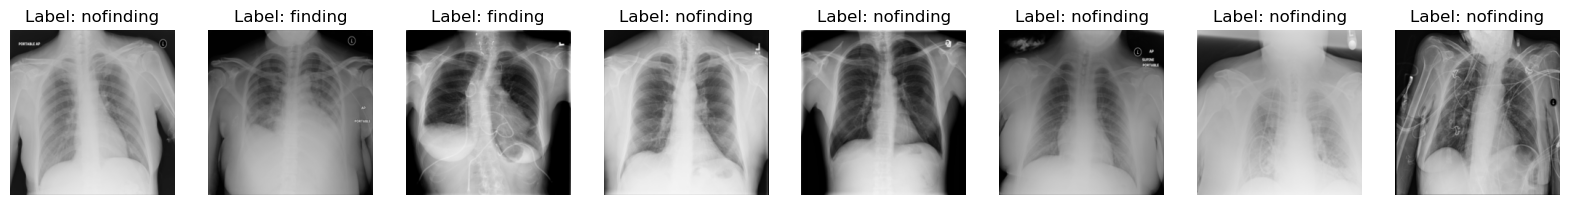

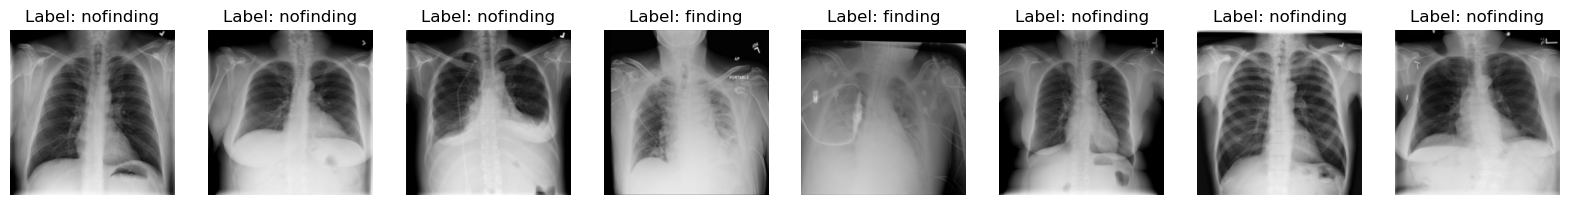

In [6]:
transform = transforms.Compose([
    transforms.Resize((227, 227)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # Normalize images
])

train_dataset = datasets.ImageFolder(root='sorted_subset/training', transform=transform)
test_dataset = datasets.ImageFolder(root='sorted_subset/testing', transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

def visualize_images(dataset, num_images=5):
    plt.figure(figsize=(20, 3))

    random_indices = random.sample(range(len(dataset)), num_images)

    for i, idx in enumerate(random_indices):
        image, label = dataset[idx]  # Get the image and label
        image = image.numpy().transpose((1, 2, 0))  # Convert from CxHxW to HxWxC
        image = (image * 0.5) + 0.5  # Undo normalization for visualization

        # Plot the image
        plt.subplot(1, num_images, i + 1)
        plt.imshow(image)
        plt.title(f'Label: {dataset.classes[label]}')
        plt.axis('off')

    plt.show()


visualize_images(train_dataset, num_images=8)
visualize_images(test_dataset, num_images=8)

## Create Xception Model

In [7]:
model = timm.create_model('mobilenetv2_100', pretrained=True)
model.classifier = torch.nn.Linear(model.classifier.in_features, 2)
model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

## Training the Model

In [8]:
def train(model, train_loader, epochs=10):
    history = {"train_loss": [], "train_acc": []}
    
    for epoch in range(epochs):
        print(f"Starting epoch {epoch+1}/{epochs}...")  # Print message when a new epoch starts
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        
        train_loss = running_loss / len(train_loader)
        train_acc = 100 * correct / total
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        
        print(f"Epoch {epoch+1}/{epochs}, Loss: {train_loss:.4f}, Accuracy: {train_acc:.2f}%")
    
    return history

history = train(model, train_loader, epochs=10)

Starting epoch 1/10...
Epoch 1/10, Loss: 0.6288, Accuracy: 65.68%
Starting epoch 2/10...
Epoch 2/10, Loss: 0.5541, Accuracy: 72.17%
Starting epoch 3/10...
Epoch 3/10, Loss: 0.4587, Accuracy: 78.66%
Starting epoch 4/10...
Epoch 4/10, Loss: 0.3071, Accuracy: 87.32%
Starting epoch 5/10...
Epoch 5/10, Loss: 0.1566, Accuracy: 94.43%
Starting epoch 6/10...
Epoch 6/10, Loss: 0.0941, Accuracy: 96.83%
Starting epoch 7/10...
Epoch 7/10, Loss: 0.0714, Accuracy: 97.53%
Starting epoch 8/10...
Epoch 8/10, Loss: 0.0636, Accuracy: 97.85%
Starting epoch 9/10...
Epoch 9/10, Loss: 0.0507, Accuracy: 98.42%
Starting epoch 10/10...
Epoch 10/10, Loss: 0.0454, Accuracy: 98.42%


## Training Metrics

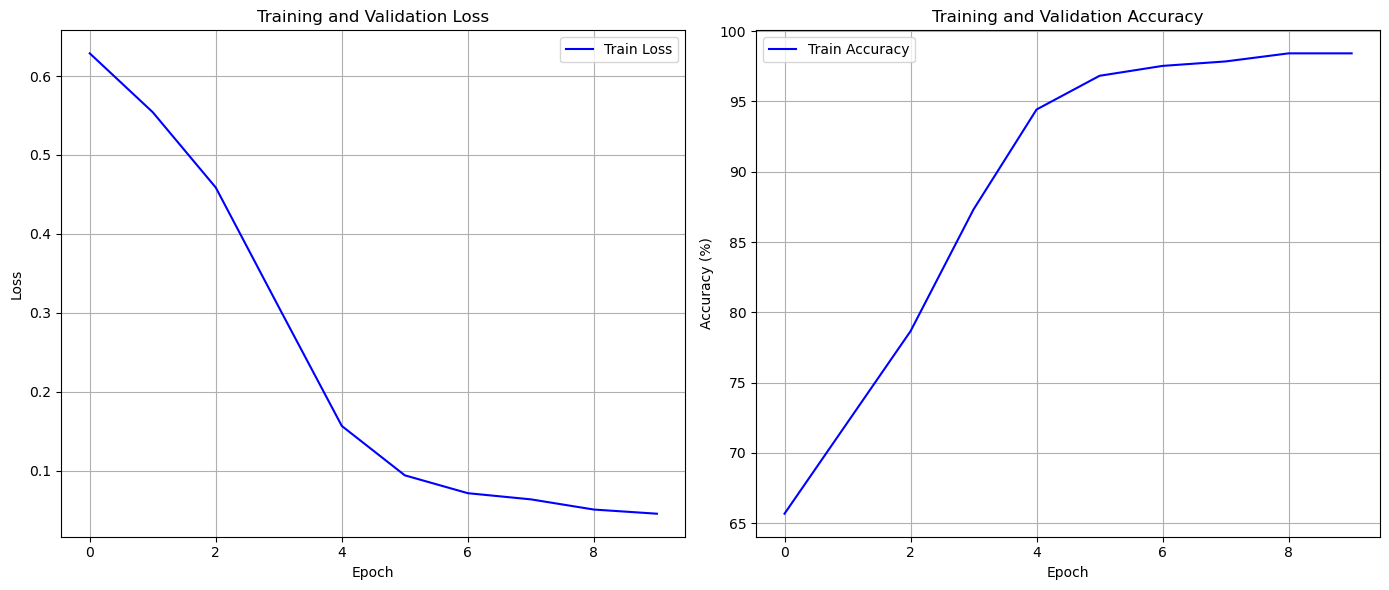

In [9]:
import matplotlib.pyplot as plt

def plot_training_history(history, val_history=None):
    plt.figure(figsize=(14, 6))

    # Train Loss vs Validation Loss
    plt.subplot(1, 2, 1)
    plt.plot(history["train_loss"], label='Train Loss', color='blue')
    if val_history:
        plt.plot(val_history["val_loss"], label='Validation Loss', color='orange')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss")
    plt.legend()
    plt.grid(True)

    # Train Accuracy vs Validation Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history["train_acc"], label='Train Accuracy', color='blue')
    if val_history:
        plt.plot(val_history["val_acc"], label='Validation Accuracy', color='orange')
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title("Training and Validation Accuracy")
    plt.legend()
    plt.grid(True)

    # Save and show the plot
    plt.tight_layout()
    plt.savefig("fine-tuning-training.png")
    plt.show()

plot_training_history(history)

## Testing phase

Test Accuracy: 60.5357%

Classification Report:
              precision    recall  f1-score   support

     finding       0.56      0.65      0.60       517
   nofinding       0.65      0.57      0.61       603

    accuracy                           0.61      1120
   macro avg       0.61      0.61      0.61      1120
weighted avg       0.61      0.61      0.61      1120



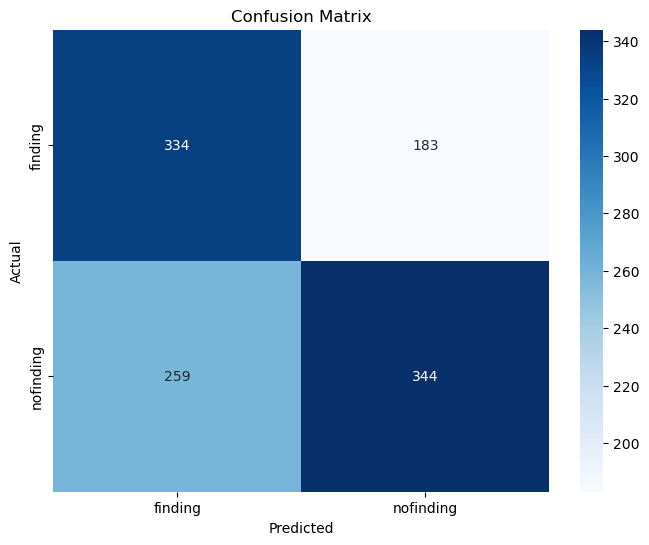

In [10]:
# Evaluation function
def evaluate(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    all_labels = []
    all_preds = []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())
    
    accuracy = 100 * correct / total
    print(f'Test Accuracy: {accuracy:.4f}%')
    
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=test_dataset.classes))
    
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=test_dataset.classes, yticklabels=test_dataset.classes)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()


evaluate(model, test_loader)

## Save Weights

In [18]:
# Save the model weights
torch.save(model.state_dict(), 'mobilenetv2_model_weights.pth')